<a href="https://colab.research.google.com/github/mpatel5/Midterm-Project-Part-2-Decision-Tree-Regression/blob/main/Patel_Midterm_Part2Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import the required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

# Load and preview data





In [ ]:
# Load dataset from a github (bikesharing.csv)
df = pd.read_csv(
    "https://raw.githubusercontent.com/raquelmangual/Midterm-datasets/main/bikesharing.csv"
)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- DataFrame Info ---")
df.info()

print("\n--- Summary Statistics (Numeric) ---")
print(df.describe())

print("\n--- Data Types (Before Cleaning) ---")
print(df.dtypes)

print("\n--- Missing Values Per Column (Before Cleaning) ---")
print(df.isnull().sum())


--- First 5 Rows ---
             timestamp  cnt   t1   t2    hum  wind_speed  weather_code  \
0  2015-01-04 00:00:00  182  3.0  2.0   93.0         6.0           3.0   
1  2015-01-04 01:00:00  138  3.0  2.5   93.0         5.0           1.0   
2  2015-01-04 02:00:00  134  2.5  2.5   96.5         0.0           1.0   
3  2015-01-04 03:00:00   72  2.0  2.0  100.0         0.0           1.0   
4  2015-01-04 04:00:00   47  2.0  0.0   93.0         6.5           1.0   

   is_holiday  is_weekend  season  
0         0.0         1.0     3.0  
1         0.0         1.0     3.0  
2         0.0         1.0     3.0  
3         0.0         1.0     3.0  
4         0.0         1.0     3.0  

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1     

# Visualize distribution of the data

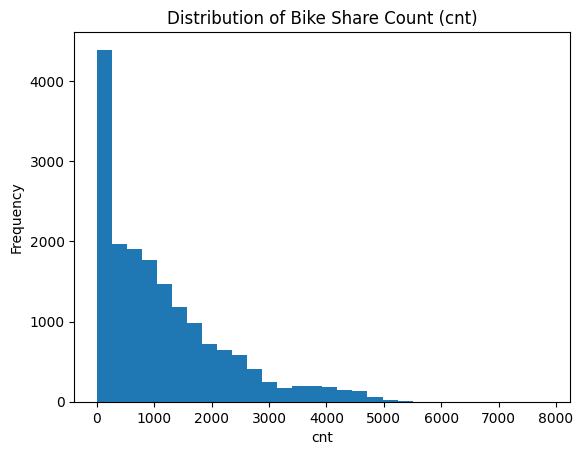

In [ ]:
plt.figure()
plt.hist(df["cnt"].dropna(), bins=30)
plt.title("Distribution of Bike Share Count (cnt)")
plt.xlabel("cnt")
plt.ylabel("Frequency")
plt.show()

# Data Cleaning and Preprocessing

In [ ]:
# Check duplicates
duplicate_count = df.duplicated().sum()
print("\n--- Duplicate Rows (Before Cleaning) ---")
print(duplicate_count)

# Remove duplicates
df_clean = df.drop_duplicates().copy()

# Handle missing values:
numeric = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric:
    df_clean.loc[:, col] = df_clean[col].fillna(df_clean[col].median())

# Confirm cleaning
print("\n--- Missing Values Per Column (After Cleaning) ---")
print(df_clean.isnull().sum())

print("\n--- Duplicate Rows (After Cleaning) ---")
print(df_clean.duplicated().sum())

print("\n--- Summary Statistics (After Cleaning) ---")
print(df_clean.describe())

print("\n--- Data Types (After Cleaning) ---")
print(df_clean.dtypes)

print("\n--- Final Data Shape ---")
print(df_clean.shape)


--- Duplicate Rows (Before Cleaning) ---
0

--- Missing Values Per Column (After Cleaning) ---
timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

--- Duplicate Rows (After Cleaning) ---
0

--- Summary Statistics (After Cleaning) ---
                cnt            t1            t2           hum    wind_speed  \
count  17414.000000  17414.000000  17414.000000  17414.000000  17414.000000   
mean    1143.101642     12.468091     11.520836     72.324954     15.913063   
std     1085.108068      5.571818      6.615145     14.313186      7.894570   
min        0.000000     -1.500000     -6.000000     20.500000      0.000000   
25%      257.000000      8.000000      6.000000     63.000000     10.000000   
50%      844.000000     12.500000     12.500000     74.500000     15.000000   
75%     1671.750000     16.000000     16.000000     83.000000     20.5

# Compare single predictors (one at a time)

In [ ]:
target = "cnt"
predictors_to_test = ["t1", "t2", "hum", "wind_speed", "weather_code", "is_holiday", "is_weekend", "season"]

print("\n--- Comparing Single Predictors (DecisionTreeRegressor) ---")

results = {}

for predictor in predictors_to_test:
    # Skip predictors not found (just in case)
    if predictor not in df_clean.columns:
        print(f"{predictor} not found in dataset columns. Skipping.")
        continue

    # Define X (feature) and y (target)
    X = df_clean[[predictor]]
    y = df_clean[target]

    # Train/test split (70% train, 30% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Train model
    model_test = DecisionTreeRegressor(max_depth=3, random_state=42)
    model_test.fit(X_train, y_train)

    # Predict on test set
    y_pred = model_test.predict(X_test)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[predictor] = {"mse": mse, "r2": r2}

    print(f"{predictor} → MSE: {mse:,.0f} | R²: {r2:.4f} ({r2*100:.2f}%)")


--- Comparing Single Predictors (DecisionTreeRegressor) ---
t1 → MSE: 1,000,569 | R²: 0.1600 (16.00%)
t2 → MSE: 1,000,155 | R²: 0.1604 (16.04%)
hum → MSE: 940,399 | R²: 0.2106 (21.06%)
wind_speed → MSE: 1,168,626 | R²: 0.0190 (1.90%)
weather_code → MSE: 1,113,232 | R²: 0.0655 (6.55%)
is_holiday → MSE: 1,186,962 | R²: 0.0036 (0.36%)
is_weekend → MSE: 1,178,915 | R²: 0.0103 (1.03%)
season → MSE: 1,140,276 | R²: 0.0428 (4.28%)


# Select best predictor and build final decision tree regression model

In [ ]:
# Predictor choice:
# I chose "hum" (humidity) because it showed the strongest relationship
# with bike rentals (cnt) in the single-predictor comparison.
# It had the highest R² and lowest MSE among all features tested,
# indicating it explains the largest portion of variance in bike rentals.

best_predictor = "hum"

print(f"\n--- Building Final Model Using: {best_predictor} ---")

X = df_clean[[best_predictor]]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(X_train, y_train)






--- Building Final Model Using: hum ---


DecisionTreeRegressor(max_depth=3, random_state=42)

# Make the predictions

In [ ]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model

In [ ]:
# Model evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Final Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² (Coefficient of Determination): {r2:.4f}")

# Display accuracy as a percentage
accuracy_pct = r2 * 100
print(f"Model Accuracy: {accuracy_pct:.2f}%")

print(
    f"\nThe Decision Tree model using '{best_predictor}' as the predictor "
    f"produced an R² value of {r2:.4f}. This means that approximately "
    f"{accuracy_pct:.2f}% of the variance in bike rental counts (cnt) is explained by "
    f"{best_predictor}. Unlike linear models, this decision tree captures non-linear "
    f"patterns by splitting the data into distinct segments based on {best_predictor} levels."
)


--- Final Model Performance ---
Mean Squared Error (MSE): 940398.875
Root Mean Squared Error (RMSE): 969.742
R² (Coefficient of Determination): 0.2106
Model Accuracy: 21.06%

The Decision Tree model using 'hum' as the predictor produced an R² value of 0.2106. This means that approximately 21.06% of the variance in bike rental counts (cnt) is explained by hum. Unlike linear models, this decision tree captures non-linear patterns by splitting the data into distinct segments based on hum levels.


# Visualize the model

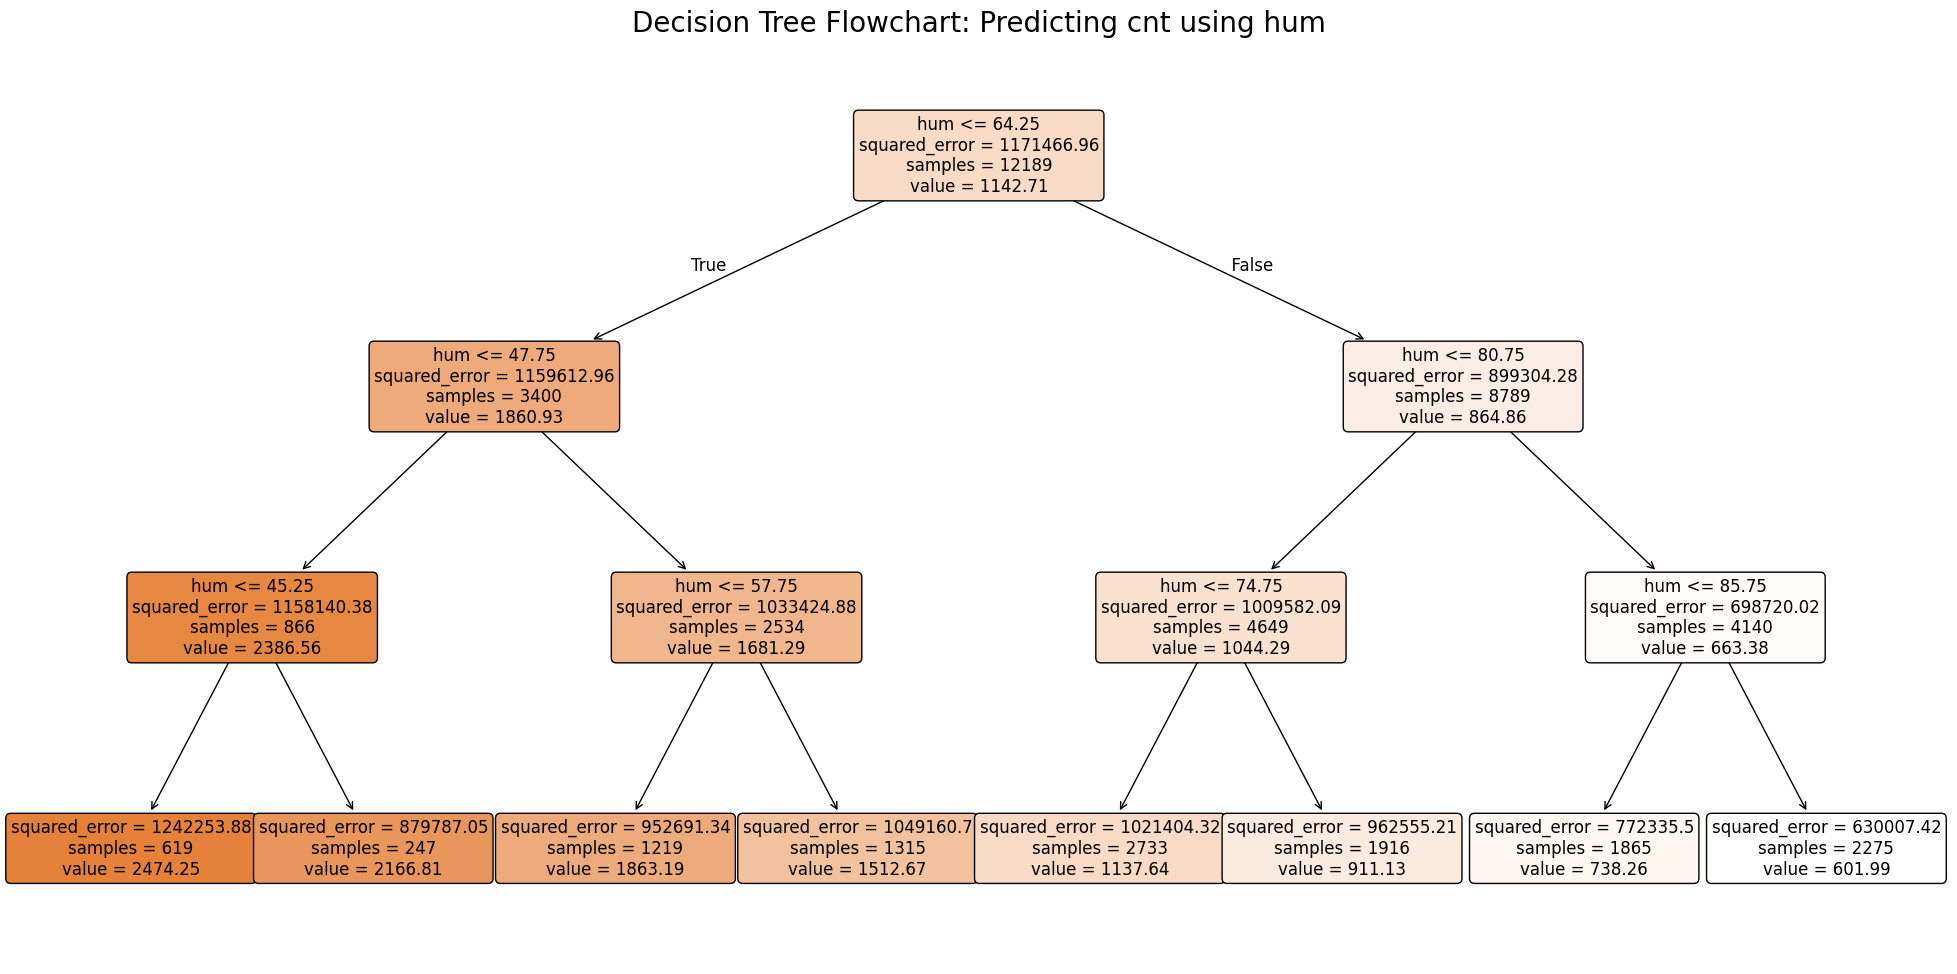

In [ ]:
# Set the figure size to be large enough to read the text
plt.figure(figsize=(25, 12))

# Plotting the tree
plot_tree(model,
          feature_names=[best_predictor],
          filled=True,
          rounded=True,
          fontsize=12,
          precision=2)

plt.title(f"Decision Tree Flowchart: Predicting {target} using {best_predictor}", fontsize=20)
plt.show()

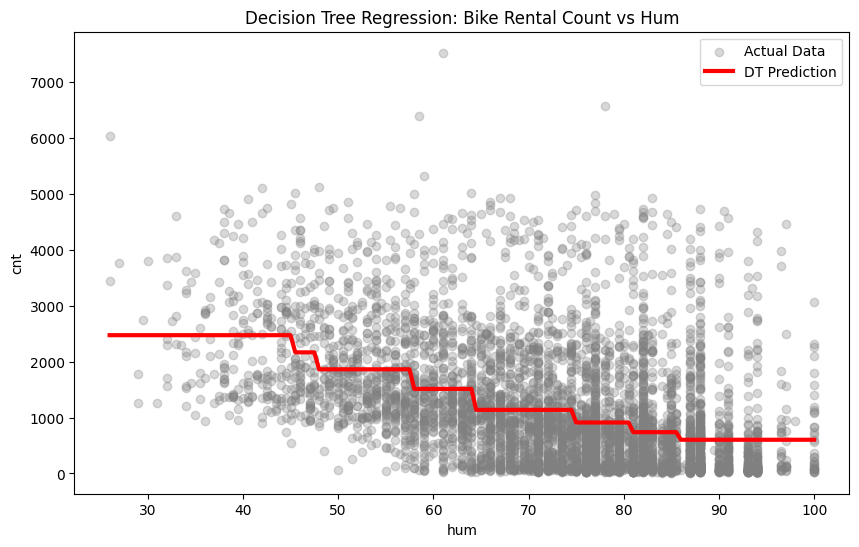

In [ ]:
# Visualize the model (cnt vs humidity)
plt.figure(figsize=(10, 6))
x = X_test[best_predictor]

# Scatter plot of actual data
plt.scatter(x, y_test, alpha=0.3, label="Actual Data", color='gray')

# Sort x and y_pred to show the "staircase" prediction line
order = np.argsort(x.values)
plt.plot(x.values[order], y_pred[order], color="red", linewidth=3, label="DT Prediction")

plt.title(f"Decision Tree Regression: Bike Rental Count vs {best_predictor.capitalize()}")
plt.xlabel(best_predictor)
plt.ylabel("cnt")
plt.legend()
plt.show()